In [14]:
using Plots
gr()
using BenchmarkTools
using PrettyPrint
using YAML
using Distributions
push!(LOAD_PATH, joinpath(homedir(), "Dropbox/Covid Modeling/Covid-ILM/source"))
using CovidSim_ilm

In [15]:
lam = log(2) / 240.0

0.0028881132523331052

In [16]:
rho = 1.0 / lam

346.24680981335126

In [17]:
rho * log(2)

240.00000000000003

In [18]:
0.9 * exp(-lam * 180.0)

0.5351432017512244

## Exponential decay

In [19]:
expdecay(t,hl) = exp(-(log(2)/hl) * t)  

expdecay (generic function with 1 method)

In [20]:
expdecay(240,240)

0.5

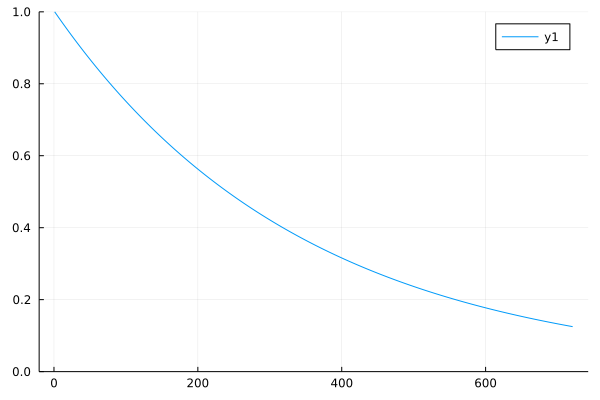

In [21]:
ts = 0:720
plot(expdecay.(ts, 240.0), ylim=(0.0, 1.0))

## Sigmoid Decay

In [22]:
sigmoid(x) = 1.0 / (1.0 + exp(-x))

sigmoid (generic function with 1 method)

In [23]:
sigmoid(x,a,b) = 1.0 / (1.0 + exp(-b * x + a))

sigmoid (generic function with 2 methods)

In [24]:
xs = range(0.0, stop=2.0, step=0.01)
# @show shifter(0.5, 0.0, 2.0, -4.5, 4.5)
shiftxs = shifter.(xs, 0.0, 2.0, -4.5, 4.5)

201-element Vector{Float64}:
 -4.5
 -4.455
 -4.41
 -4.365
 -4.32
 -4.275
 -4.23
 -4.185
 -4.14
 -4.095
 -4.05
 -4.005
 -3.96
  ⋮
  4.004999999999999
  4.049999999999999
  4.094999999999999
  4.140000000000001
  4.1850000000000005
  4.23
  4.275
  4.32
  4.365
  4.41
  4.455
  4.5

In [25]:
clamp.([-0.3, 0.0, 1.0, 2.0, 2.2], 0.0, 2.0)

5-element Vector{Float64}:
 0.0
 0.0
 1.0
 2.0
 2.0

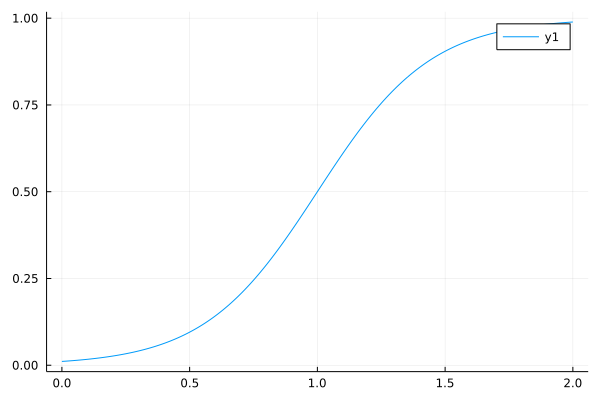

In [26]:
plot(xs,sigmoid.(shiftxs))

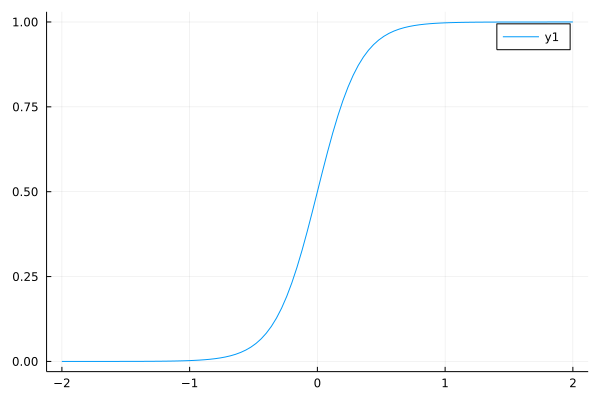

In [27]:
xs = 0.0:0.01:1.0
xs = 4.0 .* xs .- 2.0
plot(xs, sigmoid.(xs, 0.0, 6.0))

In [28]:
sigdecay(t,hl; csig=5.0) = 1.0 / (1.0 + exp.((t - hl)/(t/csig + (hl/csig))))         

sigdecay (generic function with 1 method)

In [29]:
sigmoid(5.0 * .7 * .3)

0.740774899182154

In [30]:
sigmoid(0)

0.5

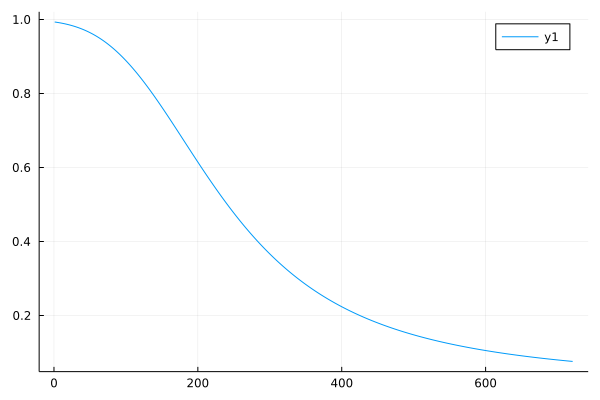

In [31]:
ts = 0:720
plot(sigdecay.(ts, 240.0))

## Linear Decay

In [32]:
# needs to be clamped at a lower bound
hl = 240
lower1 = 0.2
lower2 = 0.1

function lindecay(t, h, lower)
    y = 0.5 ./ -h * t  + 1.0
    y = y < lower ? lower : y
end


function lindecayz(t, h)
   y = (0.5/-h) * t + 1.0
   y = y < 0.0 ? 0.0 : y
end

lindecayz (generic function with 1 method)

In [33]:
@time lindecayz(400.0, 180.0)

  0.000001 seconds


0.0

In [34]:
@time lindecay(720.0, 180.0, 0.1)

  0.000001 seconds


0.1

##### Piecewise linear with 2 negative slope segments
This is based on the above, but instead of clamping to create a horizontal segment (slope = 0) we add another sloping segment where the first steeper segment reaches the desired minimum point. This depends on the minimum point (lower) and the half-life value (hl).

In [35]:
tbrk(hl, lower) = 2.0 * hl - (2.0 * hl * lower)

intercept(t, hl, lower) = -0.3 * t / hl + 1.0

function lindecay2(t,hl,lower1, lower2)
    f1 = -t * 0.5 / hl + 1.0
    if  f1 >= lower1
        f1
    else
        clamp(-t * 0.2 / hl + intercept(tbrk(hl, lower1), hl, lower1), lower2, 1.0)
    end
end

function lindecayarr(t::AbstractVector{T} where T, hl, lower1, lower2)
    arr = zeros(size(t,1))
    icept = intercept(tbrk(hl, lower1), hl, lower1)
    for i = eachindex(arr)
        f1 = -t[i] * 0.5 / hl + 1.0
        if  f1 >= lower1
            arr[i] = f1
        else
            arr[i] = clamp(-t[i] * 0.2 / hl + icept, lower2, 1.0)
        end
    end
    return arr
end

lindecayarr (generic function with 1 method)

In [36]:
hl = 240
tbend = tbrk(hl,lower1)
i = intercept(tbend, hl, lower1)
tbend,i

(384.0, 0.52)

In [37]:
@time lindecay2(280, hl, lower1, lower2);

  0.003490 seconds (6.64 k allocations: 381.976 KiB, 98.32% compilation time)


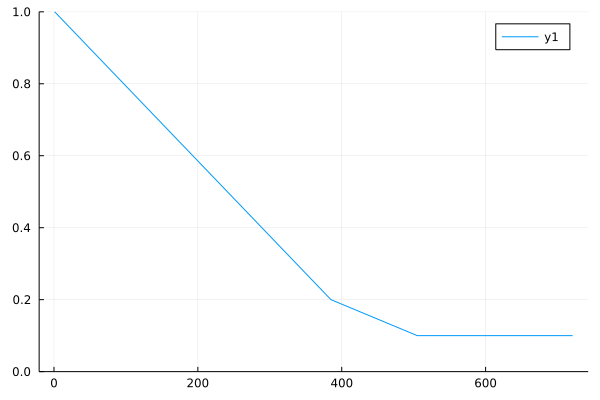

In [38]:
ts = collect(0:720)
plot(lindecayarr(ts, hl, lower1, lower2), ylim=(0.0, 1.0))

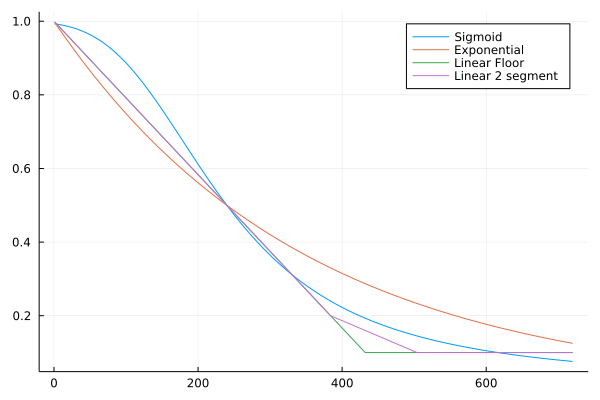

In [39]:
ts = collect(1:720)
plot(sigdecay.(ts, 240.0), label="Sigmoid")
plot!(expdecay.(ts, 240.0), label="Exponential")
plot!(lindecay.(ts, 240.0, lower2), label="Linear Floor")
plot!(lindecay2.(ts, 240.0, lower1, lower2), label="Linear 2 segment")



In [40]:

@time lindecay2.(ts, hl, lower1, lower2);

  0.035893 seconds (154.07 k allocations: 9.266 MiB, 98.39% compilation time)


In [41]:
@time lindecayarr(ts, hl, lower1, lower2);

  0.000008 seconds (1 allocation: 5.750 KiB)


In [42]:
@btime expdecay(200, 240);

  6.791 ns (0 allocations: 0 bytes)


In [43]:
@btime lindecay2(200,240, lower1, lower2);

  27.847 ns (1 allocation: 16 bytes)


In [44]:
@btime sigdecay(200, 240.0);

  0.001 ns (0 allocations: 0 bytes)


In [45]:
@btime lindecay(200, 240.0, lower2);

  27.261 ns (1 allocation: 16 bytes)


## Rise Time of Vaccine Effectiveness

In [46]:
lower = 0.1
upper = 1.0
days = 14
function riseup(t, days, lower, upper)
    clamp(t * (1.0 / days), lower, upper)
end
riseup14(t) = riseup(t, 14, 0.0, 1.0)

riseup14 (generic function with 1 method)

In [47]:
@time riseup(1, 14, 0.0, 1.0)

  0.000000 seconds


0.07142857142857142

In [48]:
@time riseup14(1)

  0.000000 seconds


0.07142857142857142

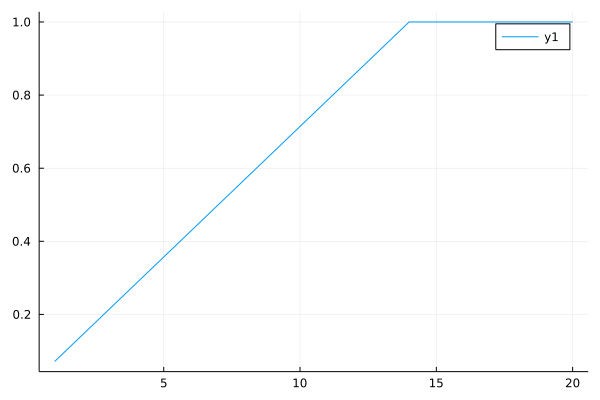

In [49]:
plot(riseup14.(1:20))

### Combining multiple factors

In [50]:
clamp_risk(x) = clamp(x, 0.0, 2.0)

clamp_risk (generic function with 1 method)

In [51]:
shifter_risk(x) = shifter(x, 0.0, 2.0, -4.5, 4.5)

shifter_risk (generic function with 1 method)

In [52]:
xs = collect(range(0.0, stop=2.2, step=0.01))

221-element Vector{Float64}:
 0.0
 0.01
 0.02
 0.03
 0.04
 0.05
 0.06
 0.07
 0.08
 0.09
 0.1
 0.11
 0.12
 ⋮
 2.09
 2.1
 2.11
 2.12
 2.13
 2.14
 2.15
 2.16
 2.17
 2.18
 2.19
 2.2

### Use this one...

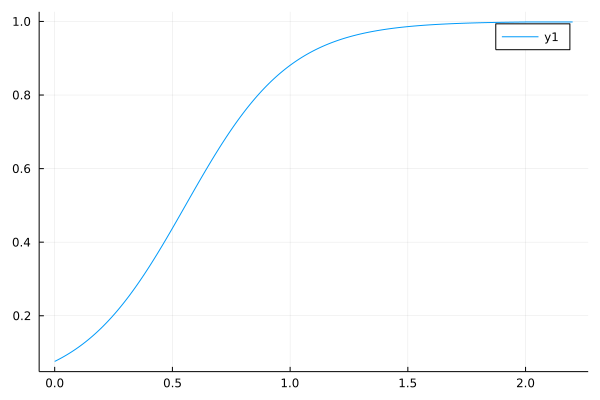

In [53]:
plot(xs,sigmoid.(shifter_risk.(clamp_risk.(xs)) .+ 2.0))

In [54]:
spread_file = joinpath(homedir(), "Dropbox", "Covid Modeling", "Covid-ILM","parameters/variant_parameters/base_variant","base_spread.yml")

"/Users/lewis/Dropbox/Covid Modeling/Covid-ILM/parameters/variant_parameters/base_variant/base_spread.yml"

In [55]:
base_spread = YAML.load_file(spread_file)

Dict{Any, Any} with 4 entries:
  "immunestrength" => 0.6
  "sendrisk"       => [0.0, 0.3, 0.65, 0.75, 0.85, 0.85, 0.75, 0.7, 0.65, 0.6  …
  "recvrisk"       => [0.1, 0.39, 0.44, 0.54, 0.56]
  "immunehalflife" => 180

In [56]:
vax_file = joinpath(homedir(), "Dropbox", "Covid Modeling", "Covid-ILM","parameters/vaccine_parameters/pfizer","pfizer_spread.yml")

"/Users/lewis/Dropbox/Covid Modeling/Covid-ILM/parameters/vaccine_parameters/pfizer/pfizer_spread.yml"

In [57]:
pfizer_spread = YAML.load_file(vax_file, dicttype=Dict{Symbol, Any})
pprintln(pfizer_spread)

{
  :day1_effect : 0.5,
  :reqdshots : 2,
  :halflife : 280,
  :name : "Pfizer",
  :delay2ndshot : 21,
  :full_effect_days : 14,
  :effectiveness : {
                     :first : {:alpha : 0.9, 
                               :base : 0.9, 
                               :delta : 0.84},
                     :second : {:alpha : 0.94, 
                                :base : 0.94, 
                                :delta : 0.88},
                     :booster : {:alpha : 0.94, 
                                 :base : 0.94, 
                                 :delta : 0.88},
                   },
}


In [58]:
sendrisk = base_spread["sendrisk"][3]
recvrisk = base_spread["recvrisk"][3]
recovfactor = 1.0 - 0.0
vaxfactor = 1.0 - 0.94
variantfactor = 1.0 - 0.0 #. ????

1.0

In [59]:
riskfactor = sendrisk * recvrisk * vaxfactor

0.017160000000000016

In [60]:

sigmoid(shifter_risk(clamp_risk(riskfactor)) + 2.0)

0.08145202040421902

In [61]:
prob = riskfactor

0.017160000000000016

In [62]:
isinfected = @fastmath rand(Binomial(1, prob)) == 1

false

### combining rise time with decline time for vax effectiveness

In [63]:
xs = range(0.0, 1.0, step=0.01)

0.0:0.01:1.0

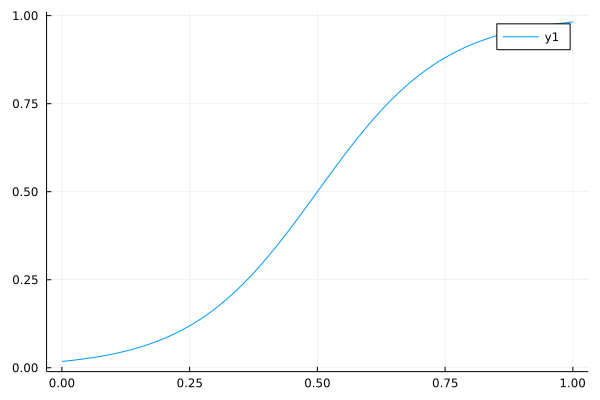

In [64]:
plot(xs, CovidSim_ilm.risk.(xs))

### Squashing functions (see sigmoid, above)

In [65]:
tanh(x) = 1.0 - 2 / exp(2.0 * x + 1.0)

tanh (generic function with 1 method)

In [66]:
sigm0to1(x) = 2.0 * sigmoid(x) - 1.0

sigm0to1 (generic function with 1 method)

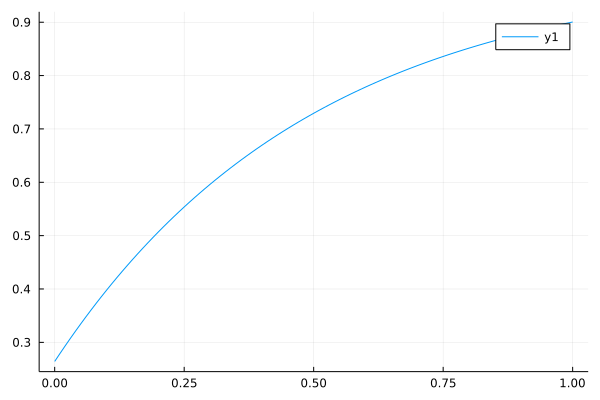

In [67]:
plot(xs, tanh.(xs))

In [68]:
asym1(x) = 1.0 - (1.0 / x)
asym2(x; a=1.0, b=1.0) = (a * x) / (a * x + b)
powersq(x; gamma=2.0, b=1.0) = ^(x/b,gamma)
simpscale(x; min=0.0, max=2.0) = (x - min) / (max - min)  # straight line
spreadin(risk) = 8.0 * risk - 4.0  # rescale risk to -4.0, 4.0

spreadin (generic function with 1 method)

In [69]:
asym1(0.5)

-1.0

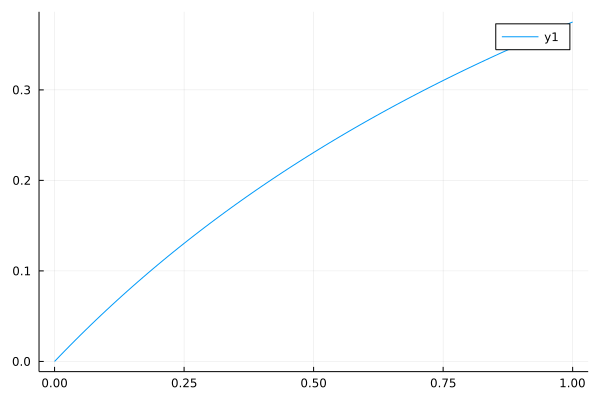

In [70]:
plot(xs, asym2.(xs,a=0.006, b=0.01))

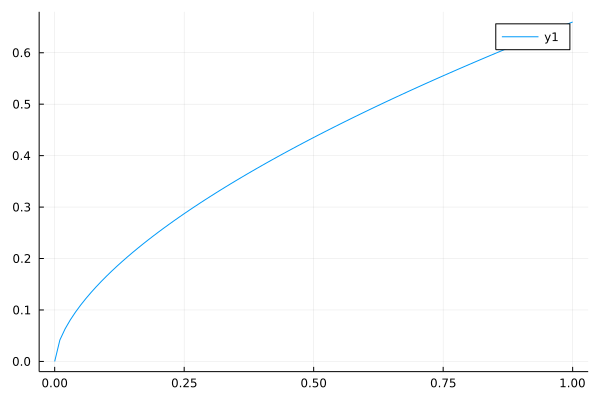

In [71]:
plot(xs, powersq.(xs,b=2.0, gamma=0.6))

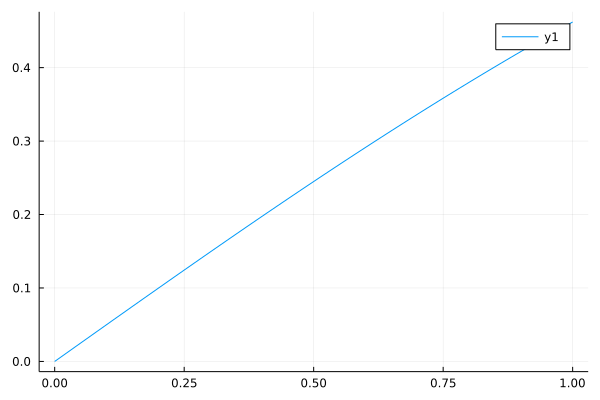

In [72]:
plot(xs, sigm0to1.(xs))

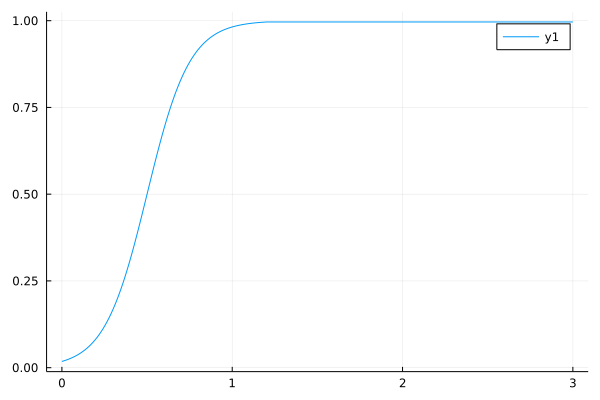

In [87]:
xs03 = 0.0:0.01:3.0
xs01 = 0.0:0.01:0.99
xs13 = 1.0:0.01:3.0
allxs = vcat(xs01, xs13)
combxs = vcat(shifter.(xs01,0.0, 0.99,-4.0, 2.0), shifter.(xs13,1.0, 3.0, 2.0, 4.0))
# plot(xs,sigmoid.(spreadin.(xs)))
#plot(xs01,sigmoid.(shifter.(xs01, 0.0, 1.0, -4.0, 4.0)))
risk_premium = 0.2
choice = xs03
plot(choice,sigmoid.(shifter.(
        clamp.(choice, 0.0, 1.0 + risk_premium),
        0.0, 1.0,-4.0, 4.0)))

In [107]:
riskfunc(x) = sigmoid.(shifter.(
        clamp.(x, 0.0, 1.0 + risk_premium),
        0.0, 1.0,-4.0, 4.0))

riskfunc (generic function with 1 method)

In [113]:
riskfunc(0.5)

0.5